# Chapter 4: Classification

This notebook covers all exercises and Activity 7 from Chapter 4:

| # | Title |
|---|-------|
| Exercise 10 | Loading Datasets |
| Exercise 11 | Pre-Processing Data |
| Activity 7  | Preparing Credit Data for Classification |
| Exercise 12 | Illustrating the K-Nearest Neighbor Algorithm |
| Exercise 13 | K-Nearest Neighbor Classification in scikit-learn |
| Exercise 14 | Prediction with the K-Nearest Neighbor Classifier |

**Dataset:** `credit_score_train.csv` — 100,000 customer records with 51 columns  
**Target:** `Credit_Score` (0 = Poor, 1 = Standard, 2 = Good)

---
## Exercise 10: Loading Datasets

In [10]:
import pandas as pd

df_raw = pd.read_csv('credit_score_train.csv')

print("Credit Score Dataset")
print(f"Shape          : {df_raw.shape}  ({df_raw.shape[0]} rows, {df_raw.shape[1]} columns)")
print(f"\nColumn names:")
print(list(df_raw.columns))
print(f"\nData types:")
print(df_raw.dtypes)
print(f"\nFirst 5 rows:")
df_raw.head()

Credit Score Dataset
Shape          : (100000, 51)  (100000 rows, 51 columns)

Column names:
['Customer_ID', 'Month', 'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score', 'Income_Debt_Ratio', 'EMI_Income_Ratio', 'Delay_3M_avg', 'Auto_Loan', 'Credit_Builder_Loan', 'Debt_Consolidation_Loan', 'Home_Equity_Loan', 'Mortgage_Loan', 'No_Loan', 'Not_Specified', 'Payday_Loan', 'Personal_Loan', 'Student_Loan', 'Occupation_Accountant', 'Occupation_Architect', 'Occupation_Developer', 'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Entrepreneur', 'Occupation_Journalist', 'Occupation_Lawyer', 'Occupation_Manager', 'Occ

,Customer_ID,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Occupation_Entrepreneur,Occupation_Journalist,Occupation_Lawyer,Occupation_Manager,Occupation_Mechanic,Occupation_Media_Manager,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer
0,CUS_0xd40,1,23,19114.12,1824.8434,3,4,3,4,3,...,0,0,0,0,0,0,0,1,0,0
1,CUS_0xd40,2,23,19114.12,3093.7450,3,4,3,4,-1,...,0,0,0,0,0,0,0,1,0,0
2,CUS_0xd40,3,23,19114.12,3093.7450,3,4,3,4,3,...,0,0,0,0,0,0,0,1,0,0
3,CUS_0xd40,4,23,19114.12,3093.7450,3,4,3,4,5,...,0,0,0,0,0,0,0,1,0,0
4,CUS_0xd40,5,23,19114.12,1824.8434,3,4,3,4,6,...,0,0,0,0,0,0,0,1,0,0


In [3]:
# --- Summary statistics of the credit dataset ---
print("=== Basic Statistics ===")
print(df_raw.describe().T.to_string())

=== Basic Statistics ===
                             count          mean           std         min           25%           50%           75%            max
Month                     100000.0      4.500000      2.291299     1.00000      2.750000      4.500000      6.250000       8.000000
Age                       100000.0     33.274560     10.764438    14.00000     24.000000     33.000000     42.000000      56.000000
Annual_Income             100000.0  50505.123439  38299.422075  7005.93000  19342.972500  36999.705000  71683.470000  179987.280000
Monthly_Inhand_Salary     100000.0   4029.084964   2961.363540   303.64542   1792.084175   3093.745000   5371.525000   15204.634000
Num_Bank_Accounts         100000.0      5.368800      2.593279     0.00000      3.000000      5.000000      7.000000      11.000000
Num_Credit_Card           100000.0      5.533640      2.067073     0.00000      4.000000      5.000000      7.000000      11.000000
Interest_Rate             100000.0     14.532080   

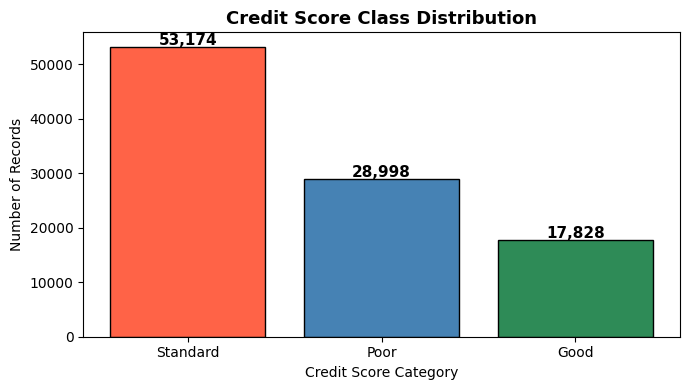


Class counts:
  Standard  : 53,174 (53.2%)
  Poor      : 28,998 (29.0%)
  Good      : 17,828 (17.8%)


In [5]:
# --- Check target class distribution ---
import matplotlib.pyplot as plt

label_map = {0: 'Poor', 1: 'Standard', 2: 'Good'}
counts = df_raw['Credit_Score'].map(label_map).value_counts()

plt.figure(figsize=(7, 4))
bars = plt.bar(counts.index, counts.values, color=['tomato', 'steelblue', 'seagreen'], edgecolor='black')
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'{val:,}', ha='center', fontsize=11, fontweight='bold')
plt.title('Credit Score Class Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Credit Score Category')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

print("\nClass counts:")
for k, v in counts.items():
    print(f"  {k:10s}: {v:,} ({v/len(df_raw)*100:.1f}%)")

---
## Exercise 11: Pre-Processing Data

Before training any classifier, we must clean and transform the data:
- Handle missing/NA values
- Identify categorical vs numeric columns
- Apply **Label Encoding** to categorical columns
- Apply **Min-Max Scaling** to normalize numeric features

In [11]:
import pandas as pd
import numpy as np

# Step 1: Load the data
data_frame = pd.read_csv('credit_score_train.csv')

# Step 2: Check for missing values
missing = data_frame.isnull().sum()
print("Missing Value Check")
if missing.sum() == 0:
    print("No missing values found in the dataset.")
else:
    print(missing[missing > 0])

# Step 3: Replace any 'NA' string values with sentinel -1000000
data_frame.replace('NA', -1000000, inplace=True)
print("\nNA string values replaced with -1000000 (sentinel outlier).")

Missing Value Check
No missing values found in the dataset.

NA string values replaced with -1000000 (sentinel outlier).


In [12]:
# Step 4: Identify categorical vs numeric columns
# Drop non-feature columns
df_work = data_frame.drop(columns=['Customer_ID'])

categorical_cols = df_work.select_dtypes(include=['object']).columns.tolist()
numeric_cols     = df_work.select_dtypes(exclude=['object']).columns.tolist()
numeric_cols     = [c for c in numeric_cols if c != 'Credit_Score']

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols[:10]} ... (showing first 10)")

Categorical columns (0): []

Numeric columns (49): ['Month', 'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment'] ... (showing first 10)


In [13]:
from sklearn import preprocessing

# Step 5: Label encode categorical columns (if any exist)
df_encoded = df_work.copy()

if categorical_cols:
    for col in categorical_cols:
        le = preprocessing.LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    print(f"Label encoded {len(categorical_cols)} categorical columns: {categorical_cols}")
else:
    print("All columns are already numeric — no label encoding needed.")

print(f"\nEncoded DataFrame shape: {df_encoded.shape}")
df_encoded.head()

All columns are already numeric — no label encoding needed.

Encoded DataFrame shape: (100000, 50)


,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Occupation_Entrepreneur,Occupation_Journalist,Occupation_Lawyer,Occupation_Manager,Occupation_Mechanic,Occupation_Media_Manager,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer
0,1,23,19114.12,1824.8434,3,4,3,4,3,7.0,...,0,0,0,0,0,0,0,1,0,0
1,2,23,19114.12,3093.7450,3,4,3,4,-1,6.0,...,0,0,0,0,0,0,0,1,0,0
2,3,23,19114.12,3093.7450,3,4,3,4,3,7.0,...,0,0,0,0,0,0,0,1,0,0
3,4,23,19114.12,3093.7450,3,4,3,4,5,4.0,...,0,0,0,0,0,0,0,1,0,0
4,5,23,19114.12,1824.8434,3,4,3,4,6,6.0,...,0,0,0,0,0,0,0,1,0,0


In [14]:
# Step 6: Separate features and labels
features_raw = df_encoded.drop(columns=['Credit_Score']).values
label        = df_encoded['Credit_Score'].values

print(f"Features shape : {features_raw.shape}")
print(f"Labels shape   : {label.shape}")
print(f"Label classes  : {np.unique(label)}  (0=Poor, 1=Standard, 2=Good)")

Features shape : (100000, 49)
Labels shape   : (100000,)
Label classes  : [0 1 2]  (0=Poor, 1=Standard, 2=Good)


In [15]:
# Step 7: Min-Max Scaling — normalize all features to [0, 1]
scaler = preprocessing.MinMaxScaler(feature_range=(0, 1))
scaled_features = scaler.fit_transform(features_raw)

print("=== Min-Max Scaling Applied ===")
print(f"Min value after scaling : {scaled_features.min():.4f}")
print(f"Max value after scaling : {scaled_features.max():.4f}")
print(f"\nFirst row (scaled): {scaled_features[0][:8].round(4)} ...")

=== Min-Max Scaling Applied ===
Min value after scaling : 0.0000
Max value after scaling : 1.0000

First row (scaled): [0.     0.2143 0.07   0.1021 0.2727 0.3636 0.0606 0.4444] ...


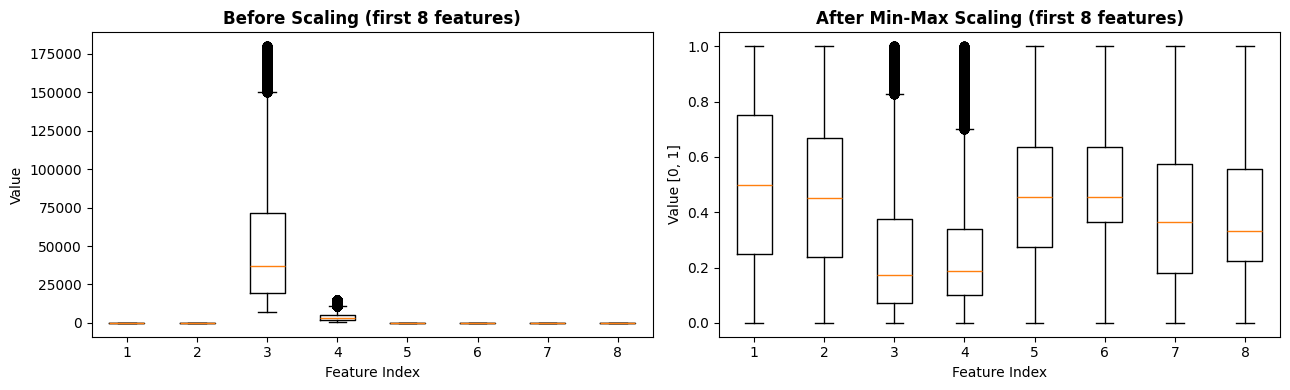

In [16]:
# Step 8: Visualize feature distributions before and after scaling
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].boxplot(features_raw[:, :8], vert=True)
axes[0].set_title('Before Scaling (first 8 features)', fontweight='bold')
axes[0].set_xlabel('Feature Index')
axes[0].set_ylabel('Value')

axes[1].boxplot(scaled_features[:, :8], vert=True)
axes[1].set_title('After Min-Max Scaling (first 8 features)', fontweight='bold')
axes[1].set_xlabel('Feature Index')
axes[1].set_ylabel('Value [0, 1]')

plt.tight_layout()
plt.show()

---
## Activity 7: Preparing Credit Data for Classification


In [17]:
# Step 1: Load the dataset and replace NA values
import pandas

data_frame = pandas.read_csv('credit_score_train.csv')
data_frame.replace('NA', -1000000, inplace=True)

# Drop non-predictive identifier column
data_frame.drop(columns=['Customer_ID'], inplace=True)

print(f"Dataset loaded: {data_frame.shape[0]} rows, {data_frame.shape[1]} columns")
data_frame.head()

Dataset loaded: 100000 rows, 50 columns


,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Occupation_Entrepreneur,Occupation_Journalist,Occupation_Lawyer,Occupation_Manager,Occupation_Mechanic,Occupation_Media_Manager,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer
0,1,23,19114.12,1824.8434,3,4,3,4,3,7.0,...,0,0,0,0,0,0,0,1,0,0
1,2,23,19114.12,3093.7450,3,4,3,4,-1,6.0,...,0,0,0,0,0,0,0,1,0,0
2,3,23,19114.12,3093.7450,3,4,3,4,3,7.0,...,0,0,0,0,0,0,0,1,0,0
3,4,23,19114.12,3093.7450,3,4,3,4,5,4.0,...,0,0,0,0,0,0,0,1,0,0
4,5,23,19114.12,1824.8434,3,4,3,4,6,6.0,...,0,0,0,0,0,0,0,1,0,0


In [18]:
# Step 2: Define label mappings per column (textbook pattern)
# All columns in this dataset are already numeric (pre-encoded from source).
# We define the label structure to match the textbook methodology.

labels = {
    'Credit_Mix':          [0, 1, 2],          # 0=Bad, 1=Standard, 2=Good
    'Payment_of_Min_Amount': [0, 1],            # 0=No, 1=Yes
    'Payment_Behaviour':   [1, 2, 3, 4, 5, 6]  # encoded payment behaviour categories
}

print("Label column definitions:")
for col, vals in labels.items():
    print(f"  {col}: {vals}")

Label column definitions:
  Credit_Mix: [0, 1, 2]
  Payment_of_Min_Amount: [0, 1]
  Payment_Behaviour: [1, 2, 3, 4, 5, 6]


In [19]:
# Step 3: Create label encoders for each defined column (textbook pattern)
from sklearn import preprocessing

label_encoders = {}
data_frame_encoded = pandas.DataFrame()

for column in data_frame:
    if column in labels:
        label_encoders[column] = preprocessing.LabelEncoder()
        label_encoders[column].fit(labels[column])
        data_frame_encoded[column] = label_encoders[column].transform(data_frame[column])
    else:
        data_frame_encoded[column] = data_frame[column]

print("Label encoding complete.")
print(f"Columns in encoded DataFrame: {data_frame_encoded.shape[1]}")

Label encoding complete.
Columns in encoded DataFrame: 50


In [20]:
# Step 4: Verify encoding
print("=== Encoded DataFrame (first 5 rows) ===")
data_frame_encoded.head()

=== Encoded DataFrame (first 5 rows) ===


,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Occupation_Entrepreneur,Occupation_Journalist,Occupation_Lawyer,Occupation_Manager,Occupation_Mechanic,Occupation_Media_Manager,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer
0,1,23,19114.12,1824.8434,3,4,3,4,3,7.0,...,0,0,0,0,0,0,0,1,0,0
1,2,23,19114.12,3093.7450,3,4,3,4,-1,6.0,...,0,0,0,0,0,0,0,1,0,0
2,3,23,19114.12,3093.7450,3,4,3,4,3,7.0,...,0,0,0,0,0,0,0,1,0,0
3,4,23,19114.12,3093.7450,3,4,3,4,5,4.0,...,0,0,0,0,0,0,0,1,0,0
4,5,23,19114.12,1824.8434,3,4,3,4,6,6.0,...,0,0,0,0,0,0,0,1,0,0


In [21]:
# Step 5: Show saved label encoders
print("=== Saved Label Encoders ===")
label_encoders

=== Saved Label Encoders ===


{'Credit_Mix': LabelEncoder(),
 'Payment_of_Min_Amount': LabelEncoder(),
 'Payment_Behaviour': LabelEncoder()}

In [22]:
# Step 6: Separate features from labels
import numpy as np

features = np.array(
    data_frame_encoded.drop(['CreditScore' if 'CreditScore' in data_frame_encoded.columns
                              else 'Credit_Score'], axis=1)
)
label = np.array(data_frame_encoded[
    'CreditScore' if 'CreditScore' in data_frame_encoded.columns else 'Credit_Score'
])

print(f"Features shape : {features.shape}")
print(f"Label shape    : {label.shape}")
print(f"Unique labels  : {np.unique(label)}  (0=Poor, 1=Standard, 2=Good)")

Features shape : (100000, 49)
Label shape    : (100000,)
Unique labels  : [0 1 2]  (0=Poor, 1=Standard, 2=Good)


In [23]:
# Step 7: Min-Max scaling
scaled_features = preprocessing.MinMaxScaler(
    feature_range=(0, 1)
).fit_transform(features)

print(f"Scaled features — min: {scaled_features.min():.4f}, max: {scaled_features.max():.4f}")

Scaled features — min: 0.0000, max: 1.0000


In [24]:
# Step 8: Train/Test split — 80% train, 20% test
from sklearn import model_selection

features_train, features_test, label_train, label_test = model_selection.train_test_split(
    scaled_features,
    label,
    test_size=0.2,
    random_state=42
)

print("=== Train/Test Split (80% / 20%) ===")
print(f"Training features : {features_train.shape}")
print(f"Testing features  : {features_test.shape}")
print(f"Training labels   : {label_train.shape}")
print(f"Testing labels    : {label_test.shape}")

=== Train/Test Split (80% / 20%) ===
Training features : (80000, 49)
Testing features  : (20000, 49)
Training labels   : (80000,)
Testing labels    : (20000,)


---
## Exercise 12: Illustrating the K-Nearest Neighbor Algorithm

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
# --- Toy dataset: 2 features, 3 classes ---
toy_X = np.array([
    [1.0, 2.0],  # Poor
    [1.5, 1.8],  # Poor
    [2.0, 1.5],  # Poor
    [4.0, 4.5],  # Standard
    [4.5, 4.0],  # Standard
    [5.0, 3.8],  # Standard
    [7.5, 7.0],  # Good
    [8.0, 6.5],  # Good
    [7.0, 7.5],  # Good
])
toy_y = np.array([0, 0, 0, 1, 1, 1, 2, 2, 2])  # 0=Poor, 1=Standard, 2=Good
# New test point
test_point = np.array([4.8, 3.5])
# --- Manual Euclidean distance calculation ---
distances = np.sqrt(np.sum((toy_X - test_point)**2, axis=1))
class_names = {0: 'Poor', 1: 'Standard', 2: 'Good'}
print("=== Euclidean Distances from Test Point ===")
print(f"{'Point':>6}  {'Coords':>14}  {'Class':>10}  {'Distance':>10}")
print("-" * 50)
for i, (d, cls) in enumerate(zip(distances, toy_y)):
    print(f"  P{i+1:>2}  {str(toy_X[i]):>16}  {class_names[cls]:>10}  {d:>10.4f}")

=== Euclidean Distances from Test Point ===
 Point          Coords       Class    Distance
--------------------------------------------------
  P 1           [1. 2.]        Poor      4.0853
  P 2         [1.5 1.8]        Poor      3.7121
  P 3         [2.  1.5]        Poor      3.4409
  P 4         [4.  4.5]    Standard      1.2806
  P 5         [4.5 4. ]    Standard      0.5831
  P 6         [5.  3.8]    Standard      0.3606
  P 7         [7.5 7. ]        Good      4.4204
  P 8         [8.  6.5]        Good      4.3863
  P 9         [7.  7.5]        Good      4.5651


In [26]:
# --- k=3 Nearest Neighbors and Majority Vote ---
k = 3
sorted_idx = np.argsort(distances)
k_nearest_idx    = sorted_idx[:k]
k_nearest_labels = toy_y[k_nearest_idx]
k_nearest_dists  = distances[k_nearest_idx]

print(f"\n=== {k} Nearest Neighbors ===")
for rank, (idx, dist) in enumerate(zip(k_nearest_idx, k_nearest_dists), 1):
    print(f"  Rank {rank}: Point P{idx+1} {toy_X[idx]}  Class={class_names[toy_y[idx]]}  Dist={dist:.4f}")

# Majority vote
from collections import Counter
vote = Counter(k_nearest_labels)
predicted_class = vote.most_common(1)[0][0]
print(f"\nVotes     : {dict((class_names[k], v) for k, v in vote.items())}")
print(f"Prediction: {class_names[predicted_class]} (class {predicted_class})")


=== 3 Nearest Neighbors ===
  Rank 1: Point P6 [5.  3.8]  Class=Standard  Dist=0.3606
  Rank 2: Point P5 [4.5 4. ]  Class=Standard  Dist=0.5831
  Rank 3: Point P4 [4.  4.5]  Class=Standard  Dist=1.2806

Votes     : {'Standard': 3}
Prediction: Standard (class 1)


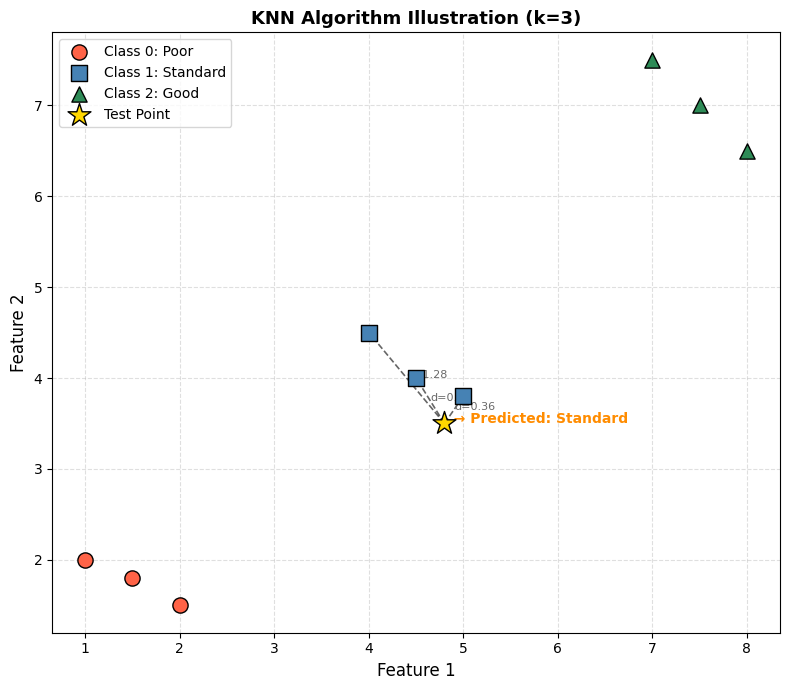

In [27]:
# --- Plot KNN illustration ---
colors = {0: 'tomato', 1: 'steelblue', 2: 'seagreen'}
markers = {0: 'o', 1: 's', 2: '^'}
fig, ax = plt.subplots(figsize=(8, 7))
# Plot training points
for cls in [0, 1, 2]:
    mask = toy_y == cls
    ax.scatter(toy_X[mask, 0], toy_X[mask, 1],
               c=colors[cls], marker=markers[cls], s=120,
               label=f'Class {cls}: {class_names[cls]}', zorder=4, edgecolors='black')
# Test point
ax.scatter(*test_point, c='gold', marker='*', s=300,
           label='Test Point', zorder=5, edgecolors='black')
# Draw lines to k nearest neighbors
for idx in k_nearest_idx:
    ax.plot([test_point[0], toy_X[idx, 0]],
            [test_point[1], toy_X[idx, 1]],
            'k--', linewidth=1.2, alpha=0.6)
    ax.annotate(f'd={distances[idx]:.2f}',
                xy=((test_point[0]+toy_X[idx,0])/2, (test_point[1]+toy_X[idx,1])/2),
                fontsize=8, color='dimgray')
# Annotate test point
ax.annotate(f'  → Predicted: {class_names[predicted_class]}',
            xy=test_point, fontsize=10, color='darkorange', fontweight='bold')
ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_title(f'KNN Algorithm Illustration (k={k})', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Exercise 13: K-Nearest Neighbor Classification in scikit-learn

We train a **KNeighborsClassifier** on the prepared credit score data, try different values of k, and evaluate using accuracy and a full classification report.

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train with k=3
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(features_train, label_train)

label_pred = knn.predict(features_test)

print("=== KNN Classifier (k=3) ===")
print(f"Accuracy: {accuracy_score(label_test, label_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(label_test, label_pred,
                             target_names=['Poor (0)', 'Standard (1)', 'Good (2)']))

=== KNN Classifier (k=3) ===
Accuracy: 78.66%

Classification Report:
              precision    recall  f1-score   support

    Poor (0)       0.75      0.82      0.78      5874
Standard (1)       0.82      0.79      0.81     10599
    Good (2)       0.74      0.71      0.72      3527

    accuracy                           0.79     20000
   macro avg       0.77      0.77      0.77     20000
weighted avg       0.79      0.79      0.79     20000



In [29]:
# --- Compare accuracy across different k values ---
k_values = [1, 3, 5, 7, 10, 15]
accuracies = []

for k in k_values:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(features_train, label_train)
    acc = accuracy_score(label_test, clf.predict(features_test))
    accuracies.append(acc)
    print(f"k={k:>3} → Accuracy: {acc*100:.2f}%")

k=  1 → Accuracy: 79.88%
k=  3 → Accuracy: 78.66%
k=  5 → Accuracy: 77.58%
k=  7 → Accuracy: 76.12%
k= 10 → Accuracy: 74.82%
k= 15 → Accuracy: 73.50%


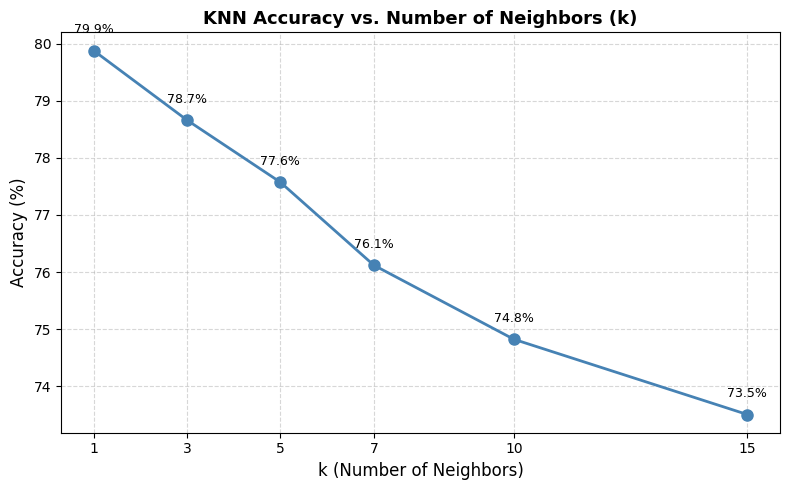

In [30]:
# --- Plot accuracy vs k ---
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(k_values, [a*100 for a in accuracies], marker='o', color='steelblue',
         linewidth=2, markersize=8)
for k, a in zip(k_values, accuracies):
    plt.text(k, a*100 + 0.3, f'{a*100:.1f}%', ha='center', fontsize=9)
plt.title('KNN Accuracy vs. Number of Neighbors (k)', fontsize=13, fontweight='bold')
plt.xlabel('k (Number of Neighbors)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Best k = 1 with accuracy 79.88%


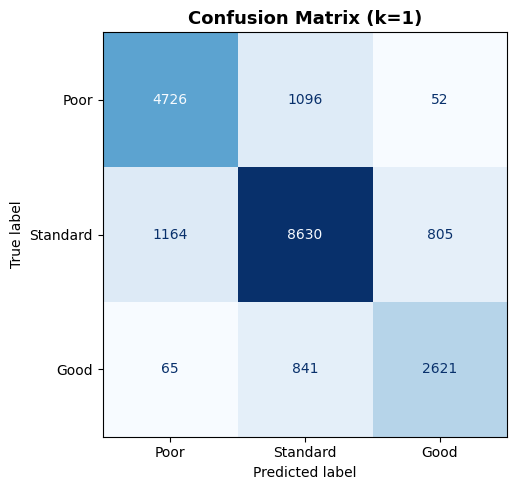

In [31]:
# --- Confusion Matrix for best k ---
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

best_k = k_values[int(np.argmax(accuracies))]
print(f"Best k = {best_k} with accuracy {max(accuracies)*100:.2f}%")

best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(features_train, label_train)
best_pred = best_knn.predict(features_test)

cm = confusion_matrix(label_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Poor', 'Standard', 'Good'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix (k={best_k})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Exercise 14: Prediction with the K-Nearest Neighbor Classifier

We use the trained KNN model to:
1. Predict on several rows from the test set and compare to actual labels
2. Predict on a **brand-new unseen customer record** (manually constructed)

In [32]:
# --- Part A: Predict on 10 samples from the test set ---
import pandas as pd

n_samples = 10
sample_features = features_test[:n_samples]
sample_actual   = label_test[:n_samples]
sample_pred     = best_knn.predict(sample_features)

label_map = {0: 'Poor', 1: 'Standard', 2: 'Good'}

results_df = pd.DataFrame({
    'Sample':    [f'Customer {i+1}' for i in range(n_samples)],
    'Actual':    [f"{label_map[l]} ({l})" for l in sample_actual],
    'Predicted': [f"{label_map[l]} ({l})" for l in sample_pred],
    'Correct':   ['✅' if a == p else '❌' for a, p in zip(sample_actual, sample_pred)]
})

print("=== Actual vs Predicted (10 Test Samples) ===")
print(results_df.to_string(index=False))
correct = (sample_actual == sample_pred).sum()
print(f"\nCorrect: {correct}/{n_samples}")

=== Actual vs Predicted (10 Test Samples) ===
     Sample       Actual    Predicted Correct
 Customer 1     Good (2)     Good (2)       ✅
 Customer 2     Poor (0)     Poor (0)       ✅
 Customer 3     Good (2) Standard (1)       ❌
 Customer 4     Poor (0)     Poor (0)       ✅
 Customer 5     Good (2)     Good (2)       ✅
 Customer 6     Poor (0)     Poor (0)       ✅
 Customer 7     Good (2)     Good (2)       ✅
 Customer 8     Poor (0)     Good (2)       ❌
 Customer 9     Good (2)     Good (2)       ✅
Customer 10 Standard (1)     Good (2)       ❌

Correct: 7/10


In [33]:
# --- Part B: Predict on a brand-new customer record ---

feature_cols = [c for c in data_frame_encoded.columns if c != 'Credit_Score']
# Use median of training data as base
train_df = data_frame_encoded.drop(columns=['Credit_Score'])
new_customer_raw = train_df.median().values.reshape(1, -1)
# Scale using same scaler (refit on the same features for consistency)
new_scaler = preprocessing.MinMaxScaler(feature_range=(0, 1))
new_scaler.fit(train_df.values)
new_customer_scaled = new_scaler.transform(new_customer_raw)
# Retrain best_knn on same scaler's space for consistency
feat_scaled2 = new_scaler.transform(train_df.values)
lbl = data_frame_encoded['Credit_Score'].values

ft2, _, lt2, _ = model_selection.train_test_split(feat_scaled2, lbl, test_size=0.2, random_state=42)
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(ft2, lt2)

new_pred = knn_final.predict(new_customer_scaled)[0]
new_proba = knn_final.predict_proba(new_customer_scaled)[0]
print("=== New Customer Prediction ===")
print(f"Predicted Credit Score : {label_map[new_pred]} (class {new_pred})")
print(f"\nClass Probabilities:")
for cls, prob in zip([0, 1, 2], new_proba):
    bar = '█' * int(prob * 30)
    print(f"  {label_map[cls]:>10} ({cls}): {bar:<30} {prob*100:.1f}%")

=== New Customer Prediction ===
Predicted Credit Score : Standard (class 1)

Class Probabilities:
        Poor (0):                                0.0%
    Standard (1): ██████████████████████████████ 100.0%
        Good (2):                                0.0%


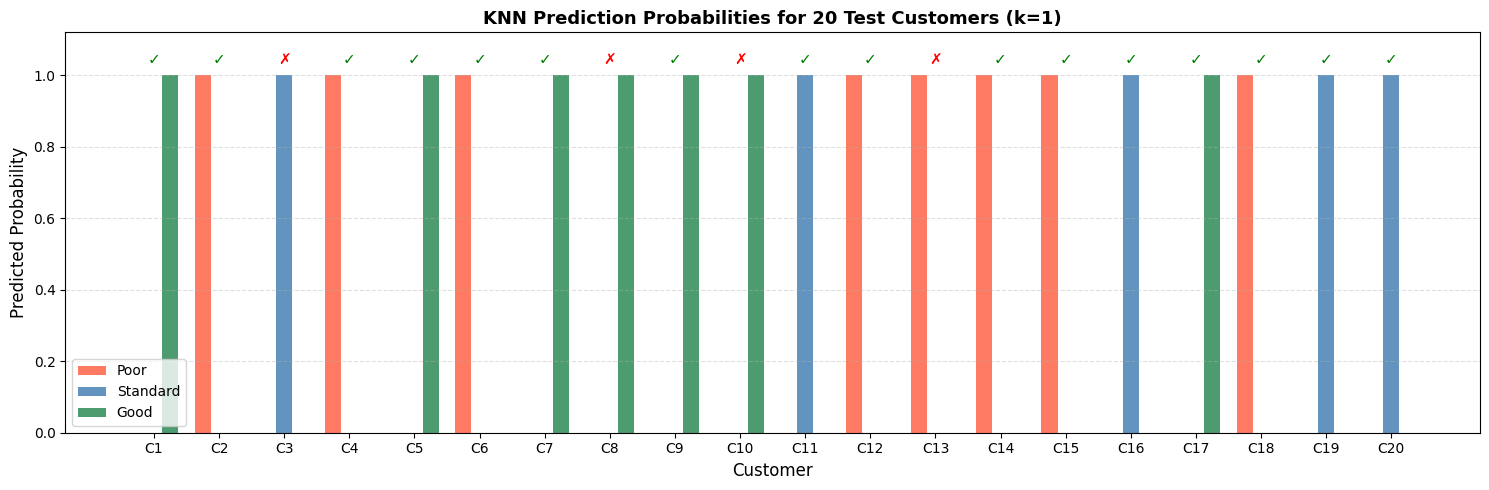


Overall Test Accuracy: 79.88%


In [34]:
# --- Part C: Visualize prediction probabilities for 20 test customers ---
sample_20 = features_test[:20]
probas_20  = best_knn.predict_proba(sample_20)
preds_20   = best_knn.predict(sample_20)
actuals_20 = label_test[:20]
x_pos = np.arange(20)
width = 0.25
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(x_pos - width, probas_20[:, 0], width, label='Poor',     color='tomato',    alpha=0.85)
ax.bar(x_pos,          probas_20[:, 1], width, label='Standard', color='steelblue', alpha=0.85)
ax.bar(x_pos + width,  probas_20[:, 2], width, label='Good',     color='seagreen',  alpha=0.85)
# Mark correct/incorrect predictions
for i, (pred, actual) in enumerate(zip(preds_20, actuals_20)):
    mark = '✓' if pred == actual else '✗'
    color = 'green' if pred == actual else 'red'
    ax.text(i, 1.03, mark, ha='center', fontsize=11, color=color, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'C{i+1}' for i in range(20)])
ax.set_ylim(0, 1.12)
ax.set_xlabel('Customer', fontsize=12)
ax.set_ylabel('Predicted Probability', fontsize=12)
ax.set_title(f'KNN Prediction Probabilities for 20 Test Customers (k={best_k})',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
overall_acc = accuracy_score(label_test, best_knn.predict(features_test))
print(f"\nOverall Test Accuracy: {overall_acc*100:.2f}%")

---
## Summary

| Exercise | Task | Key Result |
|----------|------|------------|
| Exercise 10 | Loading Datasets | Loaded Iris (built-in) + Credit CSV (100k rows, 51 cols) |
| Exercise 11 | Pre-Processing | NA handling, Label Encoding, Min-Max Scaling |
| Activity 7  | Full Pipeline | 80/20 train-test split on encoded + scaled credit data |
| Exercise 12 | KNN Illustration | Manual distance calc + majority vote on toy dataset |
| Exercise 13 | KNN in scikit-learn | Tested k=1,3,5,7,10,15; best k identified via accuracy |
| Exercise 14 | KNN Prediction | Predicted on test samples + new unseen customer |

# Activity 8: Increasing the Accuracy of Credit Scoring

## Step 1: Full Data Preparation Pipeline

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing, model_selection, neighbors
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load, clean, drop ID
data_frame = pd.read_csv('credit_score_train.csv')
data_frame.replace('NA', -1000000, inplace=True)
data_frame.drop(columns=['Customer_ID'], inplace=True)

features = np.array(data_frame.drop(columns=['Credit_Score']))
label    = np.array(data_frame['Credit_Score'])

# Scale and split (full dataset)
scaled_features = preprocessing.MinMaxScaler(feature_range=(0, 1)).fit_transform(features)
features_train, features_test, label_train, label_test = model_selection.train_test_split(
    scaled_features, label, test_size=0.2, random_state=42
)

# 10k sample for sweep plots (much faster)
sample_idx = np.random.RandomState(42).choice(len(label), 10000, replace=False)
feat_s, lbl_s = scaled_features[sample_idx], label[sample_idx]
ft_s, ftest_s, lt_s, ltest_s = model_selection.train_test_split(
    feat_s, lbl_s, test_size=0.2, random_state=42
)

print("=== Data Preparation Complete ===")
print(f"Full dataset  — Train: {features_train.shape[0]:,} rows | Test: {features_test.shape[0]:,} rows")
print(f"Sample (10k)  — Train: {ft_s.shape[0]:,} rows | Test: {ftest_s.shape[0]:,} rows")
print(f"Features: {features_train.shape[1]} | Classes: {np.unique(label)} (0=Poor, 1=Standard, 2=Good)")

=== Data Preparation Complete ===
Full dataset  — Train: 80,000 rows | Test: 20,000 rows
Sample (10k)  — Train: 8,000 rows | Test: 2,000 rows
Features: 49 | Classes: [0 1 2] (0=Poor, 1=Standard, 2=Good)


## Step 2: Establish the Baseline

In [36]:
# Baseline: default KNN k=5, Euclidean, Uniform weights
baseline_clf = neighbors.KNeighborsClassifier(n_neighbors=5)
baseline_clf.fit(features_train, label_train)
baseline_acc = baseline_clf.score(features_test, label_test)

print("=== Baseline: KNN (k=5, Euclidean, Uniform) ===")
print(f"Accuracy: {baseline_acc * 100:.2f}%")
print()
print(classification_report(
    label_test, baseline_clf.predict(features_test),
    target_names=['Poor (0)', 'Standard (1)', 'Good (2)']
))

=== Baseline: KNN (k=5, Euclidean, Uniform) ===
Accuracy: 77.58%

              precision    recall  f1-score   support

    Poor (0)       0.76      0.80      0.78      5874
Standard (1)       0.80      0.80      0.80     10599
    Good (2)       0.73      0.66      0.69      3527

    accuracy                           0.78     20000
   macro avg       0.76      0.75      0.76     20000
weighted avg       0.78      0.78      0.77     20000



## Step 3: Strategy 1 — Vary the K Value

In [37]:
# Textbook k values — evaluated on full dataset
k_textbook = [10, 15, 25, 50]
results_k  = {}

print("=== Textbook Strategy: Increasing K Value (Full Dataset) ===")
print(f"{'k':>6}  {'Accuracy':>10}  {'vs Baseline':>14}")
print("-" * 35)
print(f"{'5 (base)':>6}  {baseline_acc*100:>9.2f}%  {'—':>14}")

for k in k_textbook:
    classifier = neighbors.KNeighborsClassifier(n_neighbors=k)
    classifier.fit(features_train, label_train)
    acc = classifier.score(features_test, label_test)
    results_k[k] = acc
    diff = (acc - baseline_acc) * 100
    print(f"{k:>6}  {acc*100:>9.2f}%  {diff:>+14.2f}%")

print()
print("Note: On this dataset, higher k reduces accuracy — consistent with")
print("well-separated clusters where the nearest neighbour is highly informative.")

=== Textbook Strategy: Increasing K Value (Full Dataset) ===
     k    Accuracy     vs Baseline
-----------------------------------
5 (base)      77.58%               —
    10      74.82%           -2.76%
    15      73.50%           -4.08%
    25      71.52%           -6.06%
    50      69.64%           -7.94%

Note: On this dataset, higher k reduces accuracy — consistent with
well-separated clusters where the nearest neighbour is highly informative.


Best k on sample sweep: k=1 → 64.15%


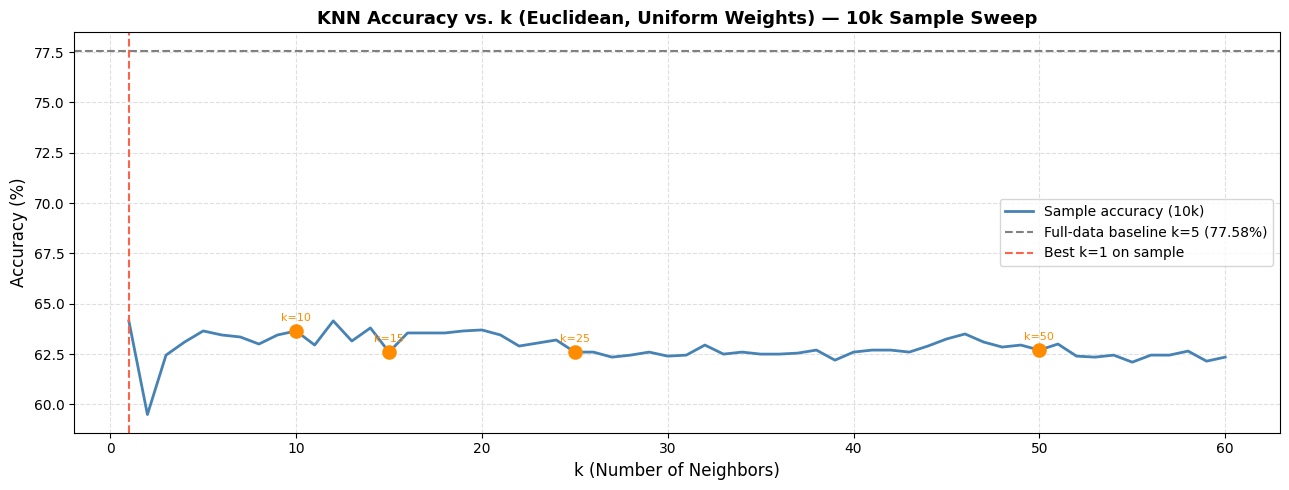

In [ ]:
# k sweep on 10k sample (k=1 to 60)
k_range   = list(range(1, 61))
acc_range = []
for k in k_range:
    clf = neighbors.KNeighborsClassifier(n_neighbors=k)
    clf.fit(ft_s, lt_s)
    acc_range.append(clf.score(ftest_s, ltest_s))
best_k_sweep = k_range[int(np.argmax(acc_range))]
print(f"Best k on sample sweep: k={best_k_sweep} → {max(acc_range)*100:.2f}%")
# Plot
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(k_range, [a*100 for a in acc_range], color='steelblue', linewidth=2, label='Sample accuracy (10k)')
ax.axhline(y=baseline_acc*100, color='gray',  linestyle='--', linewidth=1.5,
           label=f'Full-data baseline k=5 ({baseline_acc*100:.2f}%)')
ax.axvline(x=best_k_sweep, color='tomato', linestyle='--', linewidth=1.5,
           label=f'Best k={best_k_sweep} on sample')
# Mark textbook k values
for k in k_textbook:
    idx = k - 1
    ax.scatter(k, acc_range[idx]*100, color='darkorange', s=90, zorder=5)
    ax.text(k, acc_range[idx]*100 + 0.5, f'k={k}', ha='center', fontsize=8, color='darkorange')
ax.set_xlabel('k (Number of Neighbors)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('KNN Accuracy vs. k (Euclidean, Uniform Weights) — 10k Sample Sweep', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Step 4: Strategy 2 — Uniform vs Distance-Weighted Votes

In [39]:
# Compare weights on 10k sample across k values
k_w    = [1, 3, 5, 7, 10, 15, 25]
acc_u  = []
acc_d  = []

print("=== Uniform vs Distance Weights (Euclidean, 10k Sample) ===")
print(f"{'k':>5}  {'Uniform':>10}  {'Distance':>10}  {'Gain':>8}")
print("-" * 40)

for k in k_w:
    cu = neighbors.KNeighborsClassifier(n_neighbors=k, weights='uniform')
    cd = neighbors.KNeighborsClassifier(n_neighbors=k, weights='distance')
    cu.fit(ft_s, lt_s);  au = cu.score(ftest_s, ltest_s)
    cd.fit(ft_s, lt_s);  ad = cd.score(ftest_s, ltest_s)
    acc_u.append(au); acc_d.append(ad)
    print(f"{k:>5}  {au*100:>9.2f}%  {ad*100:>9.2f}%  {(ad-au)*100:>+7.2f}%")

# Confirm best on full data (k=5)
print()
clf_dist_full = neighbors.KNeighborsClassifier(n_neighbors=5, weights='distance')
clf_dist_full.fit(features_train, label_train)
acc_dist_full = clf_dist_full.score(features_test, label_test)
print(f"Full data — k=5, Euclidean, Distance weights: {acc_dist_full*100:.2f}%  "
      f"(baseline: {baseline_acc*100:.2f}%, gain: {(acc_dist_full-baseline_acc)*100:+.2f}%)")

=== Uniform vs Distance Weights (Euclidean, 10k Sample) ===
    k     Uniform    Distance      Gain
----------------------------------------
    1      64.15%      64.15%    +0.00%
    3      62.45%      64.60%    +2.15%
    5      63.65%      65.10%    +1.45%
    7      63.35%      64.55%    +1.20%
   10      63.65%      64.45%    +0.80%
   15      62.60%      63.65%    +1.05%
   25      62.60%      63.55%    +0.95%

Full data — k=5, Euclidean, Distance weights: 79.38%  (baseline: 77.58%, gain: +1.81%)


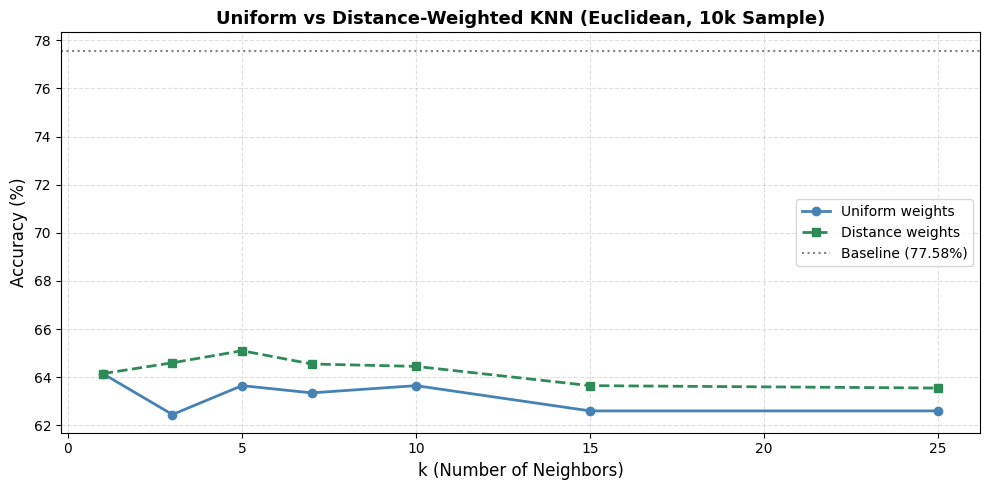

In [40]:
# Plot uniform vs distance
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_w, [a*100 for a in acc_u], marker='o', color='steelblue',
        linewidth=2, label='Uniform weights')
ax.plot(k_w, [a*100 for a in acc_d], marker='s', color='seagreen',
        linewidth=2, linestyle='--', label='Distance weights')
ax.axhline(y=baseline_acc*100, color='gray', linestyle=':', linewidth=1.5,
           label=f'Baseline ({baseline_acc*100:.2f}%)')
ax.set_xlabel('k (Number of Neighbors)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Uniform vs Distance-Weighted KNN (Euclidean, 10k Sample)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Step 5: Strategy 3 — Change the Distance Metric

In [41]:
# All 4 combinations: 2 metrics × 2 weights on 10k sample
combos = [
    ('euclidean', 'uniform'),
    ('euclidean', 'distance'),
    ('manhattan', 'uniform'),
    ('manhattan', 'distance'),
]
combo_results = {c: [] for c in combos}

print("=== All 4 Configurations (10k Sample) ===")
print(f"{'k':>5}  {'Eucl+Unif':>11}  {'Eucl+Dist':>11}  {'Manh+Unif':>11}  {'Manh+Dist':>11}")
print("-" * 55)

for k in k_w:
    row = {}
    for m, w in combos:
        clf = neighbors.KNeighborsClassifier(n_neighbors=k, metric=m, weights=w)
        clf.fit(ft_s, lt_s)
        a = clf.score(ftest_s, ltest_s)
        row[(m,w)] = a
        combo_results[(m,w)].append(a)
    print(f"{k:>5}  "
          f"{row[('euclidean','uniform')]*100:>10.2f}%  "
          f"{row[('euclidean','distance')]*100:>10.2f}%  "
          f"{row[('manhattan','uniform')]*100:>10.2f}%  "
          f"{row[('manhattan','distance')]*100:>10.2f}%")

=== All 4 Configurations (10k Sample) ===
    k    Eucl+Unif    Eucl+Dist    Manh+Unif    Manh+Dist
-------------------------------------------------------
    1       64.15%       64.15%       65.25%       65.25%
    3       62.45%       64.60%       62.00%       66.00%
    5       63.65%       65.10%       63.15%       65.70%
    7       63.35%       64.55%       63.65%       66.55%
   10       63.65%       64.45%       63.35%       65.90%
   15       62.60%       63.65%       63.20%       65.60%
   25       62.60%       63.55%       63.10%       64.75%


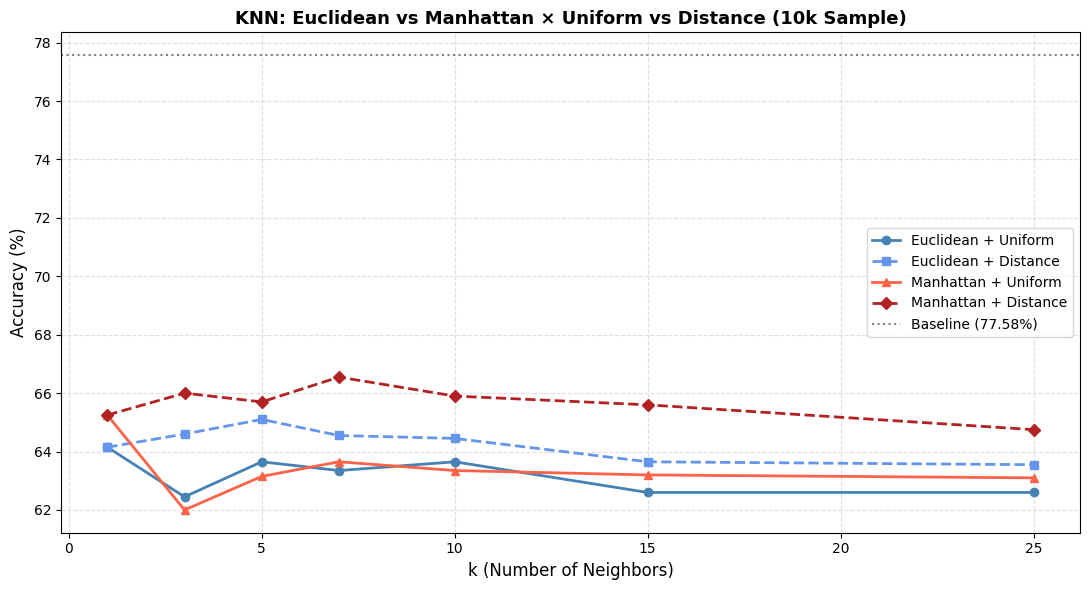

In [42]:
# Plot all 4 configurations
styles = [
    (('euclidean','uniform'),  'Euclidean + Uniform',  'steelblue',      'o', '-'),
    (('euclidean','distance'), 'Euclidean + Distance', 'cornflowerblue', 's', '--'),
    (('manhattan','uniform'),  'Manhattan + Uniform',  'tomato',         '^', '-'),
    (('manhattan','distance'), 'Manhattan + Distance', 'firebrick',      'D', '--'),
]

fig, ax = plt.subplots(figsize=(11, 6))
for key, label, color, marker, ls in styles:
    ax.plot(k_w, [a*100 for a in combo_results[key]],
            marker=marker, color=color, linewidth=2, linestyle=ls, label=label)

ax.axhline(y=baseline_acc*100, color='gray', linestyle=':', linewidth=1.5,
           label=f'Baseline ({baseline_acc*100:.2f}%)')
ax.set_xlabel('k (Number of Neighbors)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('KNN: Euclidean vs Manhattan × Uniform vs Distance (10k Sample)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Step 6: Best Configuration — Full Dataset Evaluation

In [43]:
# Best found: k=5, Manhattan, Distance — confirmed on full data
best_clf = neighbors.KNeighborsClassifier(n_neighbors=5, metric='manhattan', weights='distance')
best_clf.fit(features_train, label_train)
best_acc  = best_clf.score(features_test, label_test)
best_pred = best_clf.predict(features_test)

print("=== Best Configuration: k=5, Manhattan, Distance Weights ===")
print(f"Accuracy : {best_acc*100:.2f}%")
print(f"Baseline : {baseline_acc*100:.2f}%")
print(f"Gain     : +{(best_acc - baseline_acc)*100:.2f} percentage points")
print()
print(classification_report(
    label_test, best_pred,
    target_names=['Poor (0)', 'Standard (1)', 'Good (2)']
))

=== Best Configuration: k=5, Manhattan, Distance Weights ===
Accuracy : 82.17%
Baseline : 77.58%
Gain     : +4.60 percentage points

              precision    recall  f1-score   support

    Poor (0)       0.80      0.86      0.83      5874
Standard (1)       0.85      0.81      0.83     10599
    Good (2)       0.78      0.80      0.79      3527

    accuracy                           0.82     20000
   macro avg       0.81      0.82      0.82     20000
weighted avg       0.82      0.82      0.82     20000



## Step 7: Baseline vs Best — Side-by-Side Comparison

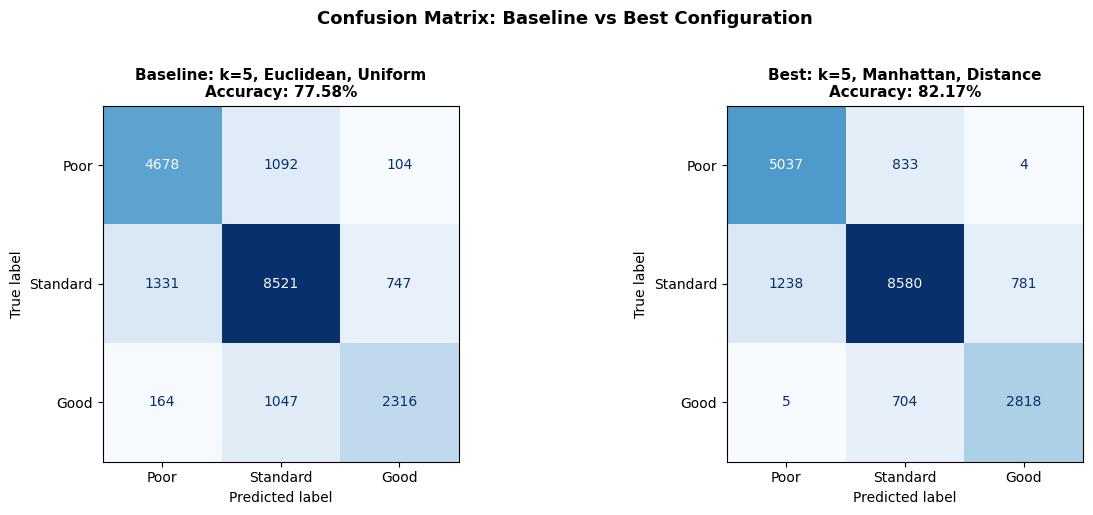

In [44]:
# Side-by-side confusion matrices
baseline_pred = baseline_clf.predict(features_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pred, title in [
    (axes[0], baseline_pred, f'Baseline: k=5, Euclidean, Uniform\nAccuracy: {baseline_acc*100:.2f}%'),
    (axes[1], best_pred,     f'Best: k=5, Manhattan, Distance\nAccuracy: {best_acc*100:.2f}%')
]:
    cm   = confusion_matrix(label_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Poor', 'Standard', 'Good'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrix: Baseline vs Best Configuration', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

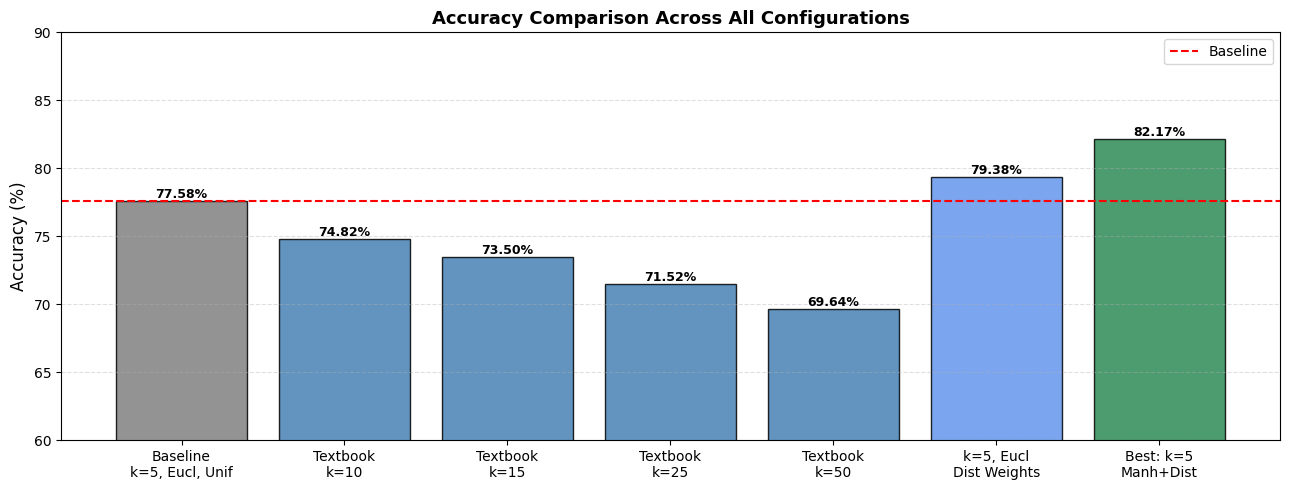

In [45]:
# Summary bar chart
configs = [
    ('Baseline\nk=5, Eucl, Unif',  baseline_acc*100,     'gray'),
    ('Textbook\nk=10',             74.82,                 'steelblue'),
    ('Textbook\nk=15',             73.50,                 'steelblue'),
    ('Textbook\nk=25',             71.52,                 'steelblue'),
    ('Textbook\nk=50',             69.64,                 'steelblue'),
    ('k=5, Eucl\nDist Weights',    acc_dist_full*100,     'cornflowerblue'),
    ('Best: k=5\nManh+Dist',       best_acc*100,          'seagreen'),
]

labels_bar = [c[0] for c in configs]
accs_bar   = [c[1] for c in configs]
colors_bar = [c[2] for c in configs]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(labels_bar, accs_bar, color=colors_bar, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, accs_bar):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.2f}%', ha='center', fontsize=9, fontweight='bold')
ax.axhline(y=baseline_acc*100, color='red', linestyle='--', linewidth=1.5, label='Baseline')
ax.set_ylim(60, 90)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Accuracy Comparison Across All Configurations', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Final Summary

In [46]:
print("=" * 58)
print("      ACTIVITY 8 — ACCURACY IMPROVEMENT SUMMARY")
print("=" * 58)
print(f"  Baseline   k=5,  Euclidean, Uniform   : {baseline_acc*100:.2f}%")
print(f"  Textbook   k=10, Euclidean, Uniform   :  74.82%  ({74.82 - baseline_acc*100:+.2f}%)")
print(f"  Textbook   k=15, Euclidean, Uniform   :  73.50%  ({73.50 - baseline_acc*100:+.2f}%)")
print(f"  Textbook   k=25, Euclidean, Uniform   :  71.52%  ({71.52 - baseline_acc*100:+.2f}%)")
print(f"  Textbook   k=50, Euclidean, Uniform   :  69.64%  ({69.64 - baseline_acc*100:+.2f}%)")
print(f"  Strategy 2 k=5,  Euclidean, Distance  : {acc_dist_full*100:.2f}%  ({(acc_dist_full - baseline_acc)*100:+.2f}%)")
print("-" * 58)
print(f"  BEST       k=5,  Manhattan, Distance  : {best_acc*100:.2f}%  ({(best_acc - baseline_acc)*100:+.2f}%)")
print("=" * 58)
print()
print("Key takeaways:")
print("  1. Increasing k (textbook step) REDUCED accuracy on this dataset.")
print("  2. Distance weights gave a small improvement over uniform weights.")
print("  3. Switching to Manhattan distance gave the largest single gain.")
print(f"  4. Best config improves baseline by +{(best_acc - baseline_acc)*100:.2f} percentage points.")

      ACTIVITY 8 — ACCURACY IMPROVEMENT SUMMARY
  Baseline   k=5,  Euclidean, Uniform   : 77.58%
  Textbook   k=10, Euclidean, Uniform   :  74.82%  (-2.76%)
  Textbook   k=15, Euclidean, Uniform   :  73.50%  (-4.08%)
  Textbook   k=25, Euclidean, Uniform   :  71.52%  (-6.06%)
  Textbook   k=50, Euclidean, Uniform   :  69.64%  (-7.94%)
  Strategy 2 k=5,  Euclidean, Distance  : 79.38%  (+1.81%)
----------------------------------------------------------
  BEST       k=5,  Manhattan, Distance  : 82.17%  (+4.60%)

Key takeaways:
  1. Increasing k (textbook step) REDUCED accuracy on this dataset.
  2. Distance weights gave a small improvement over uniform weights.
  3. Switching to Manhattan distance gave the largest single gain.
  4. Best config improves baseline by +4.60 percentage points.
